# Simulated A/B Test Analysis

This notebook demonstrates a simulated A/B test for an e-commerce product feature.

The experiment evaluates a new personalized recommendation block designed to increase the probability of a repeat purchase within 30 days.

The experiment data is simulated because the Olist dataset does not contain real experimental group assignments. Baseline assumptions are informed by the customer behavior observed in the project, but the resulting experiment should be interpreted as an analytical case study rather than a real Olist experiment.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
    proportion_effectsize,
)

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.4f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Experiment Design

### Business Context

The marketplace plans to introduce a personalized recommendation block after a customer's first completed order.

The feature is expected to help customers discover relevant products and increase the probability of placing another order within 30 days.

### Experimental Groups

- **Control group:** customers receive the existing post-purchase experience.
- **Treatment group:** customers receive the new personalized recommendation block.

### Randomization Unit

The randomization unit is the unique customer. Each customer must belong to only one experimental group to prevent contamination between variants.

### Primary Metric

The primary metric is the **30-day repeat purchase conversion rate**:

\[
\text{Conversion Rate}
=
\frac{\text{Customers with a repeat purchase within 30 days}}
{\text{Eligible customers}}
\]

### Hypotheses

- **Null hypothesis \(H_0\):** the treatment does not increase 30-day repeat purchase conversion.
- **Alternative hypothesis \(H_1\):** the treatment increases 30-day repeat purchase conversion.

### Significance Level and Power

- significance level: \($\alpha$ = 0.05\);
- statistical power: \(1-$\beta$ = 0.80\);
- allocation ratio: 50% control and 50% treatment.

## 2. Baseline Metric and Sample Size

In [2]:
baseline_conversion = 0.025
relative_mde = 0.20

treatment_conversion = (
    baseline_conversion
    * (1 + relative_mde)
)

absolute_mde = (
    treatment_conversion
    - baseline_conversion
)

significance_level = 0.05
statistical_power = 0.80

In [3]:
experiment_parameters = pd.DataFrame(
    {
        "parameter": [
            "Baseline conversion",
            "Relative MDE",
            "Absolute MDE",
            "Expected treatment conversion",
            "Significance level",
            "Statistical power",
        ],
        "value": [
            baseline_conversion,
            relative_mde,
            absolute_mde,
            treatment_conversion,
            significance_level,
            statistical_power,
        ],
    }
)

experiment_parameters

,parameter,value
0,Baseline conversion,0.0250
1,Relative MDE,0.2000
2,Absolute MDE,0.0050
3,Expected treatment conversion,0.0300
4,Significance level,0.0500
5,Statistical power,0.8000


In [4]:
effect_size = proportion_effectsize(
    baseline_conversion,
    treatment_conversion,
)

power_analysis = NormalIndPower()

sample_size_per_group = power_analysis.solve_power(
    effect_size=effect_size,
    alpha=significance_level,
    power=statistical_power,
    ratio=1,
    alternative="two-sided",
)

sample_size_per_group = int(
    np.ceil(sample_size_per_group)
)

sample_size_per_group

16759

In [5]:
total_sample_size = (
    2 * sample_size_per_group
)

sample_size_summary = pd.DataFrame(
    {
        "group": [
            "Control",
            "Treatment",
            "Total",
        ],
        "required_customers": [
            sample_size_per_group,
            sample_size_per_group,
            total_sample_size,
        ],
    }
)

sample_size_summary

,group,required_customers
0,Control,16759
1,Treatment,16759
2,Total,33518


In [6]:
relative_effects = np.arange(
    0.10,
    0.51,
    0.05,
)

sample_size_by_mde = []

for relative_effect in relative_effects:
    expected_conversion = (
        baseline_conversion
        * (1 + relative_effect)
    )

    current_effect_size = proportion_effectsize(
        baseline_conversion,
        expected_conversion,
    )

    current_sample_size = power_analysis.solve_power(
        effect_size=current_effect_size,
        alpha=significance_level,
        power=statistical_power,
        ratio=1,
        alternative="two-sided",
    )

    sample_size_by_mde.append(
        {
            "relative_mde_percent": (
                relative_effect * 100
            ),
            "sample_size_per_group": int(
                np.ceil(current_sample_size)
            ),
        }
    )

sample_size_by_mde = pd.DataFrame(
    sample_size_by_mde
)

sample_size_by_mde

,relative_mde_percent,sample_size_per_group
0,10.0000,64164
1,15.0000,29159
2,20.0000,16759
3,25.0000,10952
4,30.0000,7760
5,35.0000,5814
6,40.0000,4537
7,45.0000,3652
8,50.0000,3012


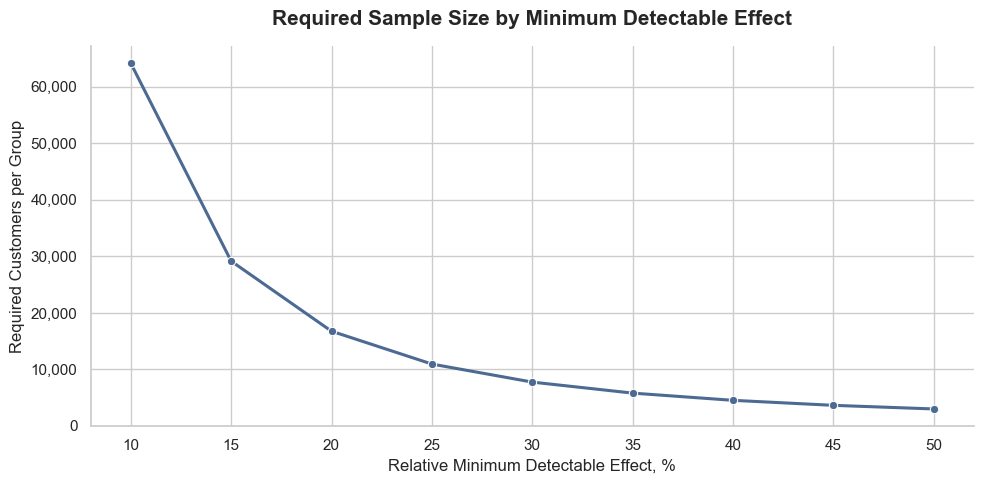

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=sample_size_by_mde,
    x="relative_mde_percent",
    y="sample_size_per_group",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Required Sample Size by Minimum Detectable Effect",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Relative Minimum Detectable Effect, %")
ax.set_ylabel("Required Customers per Group")

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{int(value):,}"
    )
)

sns.despine()
plt.tight_layout()
plt.show()

### Sample Size Findings

The required sample size decreases sharply as the minimum detectable effect increases.

Detecting a relatively small uplift of 10% requires more than 60,000 customers per group, while a 20% relative uplift requires approximately 17,000 customers per group. For larger effects, the required sample becomes substantially smaller.

This illustrates an important experiment-design trade-off: detecting small improvements requires more traffic, longer experiment duration, or lower statistical power. The selected 20% relative MDE represents an absolute increase in conversion from 2.5% to 3.0% and provides a reasonable balance between sensitivity and feasibility for this simulated case.

## 3. Simulated Experiment Data

In [8]:
control_size = sample_size_per_group
treatment_size = sample_size_per_group

In [9]:
control_data = pd.DataFrame(
    {
        "customer_id": [
            f"control_{customer_id}"
            for customer_id in range(control_size)
        ],
        "group": "Control",
        "repeat_purchase_30d": rng.binomial(
            n=1,
            p=baseline_conversion,
            size=control_size,
        ),
    }
)

treatment_data = pd.DataFrame(
    {
        "customer_id": [
            f"treatment_{customer_id}"
            for customer_id in range(treatment_size)
        ],
        "group": "Treatment",
        "repeat_purchase_30d": rng.binomial(
            n=1,
            p=treatment_conversion,
            size=treatment_size,
        ),
    }
)

In [10]:
experiment_data = pd.concat(
    [
        control_data,
        treatment_data,
    ],
    ignore_index=True,
)

experiment_data.head()

,customer_id,group,repeat_purchase_30d
0,control_0,Control,0
1,control_1,Control,0
2,control_2,Control,0
3,control_3,Control,0
4,control_4,Control,0


In [11]:
experiment_data.shape

(33518, 3)

In [12]:
experiment_data["group"].value_counts()

group
Control      16759
Treatment    16759
Name: count, dtype: int64

## 4. Sample Ratio Mismatch Check

In [13]:
observed_group_sizes = (
    experiment_data["group"]
    .value_counts()
    .sort_index()
)

expected_group_sizes = np.array(
    [
        len(experiment_data) / 2,
        len(experiment_data) / 2,
    ]
)

observed_group_sizes

group
Control      16759
Treatment    16759
Name: count, dtype: int64

In [14]:
srm_result = stats.chisquare(
    f_obs=observed_group_sizes.values,
    f_exp=expected_group_sizes,
)

srm_statistic = srm_result.statistic
srm_p_value = srm_result.pvalue

srm_statistic, srm_p_value

(np.float64(0.0), np.float64(1.0))

In [15]:
srm_summary = pd.DataFrame(
    {
        "metric": [
            "Control customers",
            "Treatment customers",
            "Chi-square statistic",
            "SRM p-value",
        ],
        "value": [
            observed_group_sizes["Control"],
            observed_group_sizes["Treatment"],
            srm_statistic,
            srm_p_value,
        ],
    }
)

srm_summary

,metric,value
0,Control customers,"16,759.0000"
1,Treatment customers,"16,759.0000"
2,Chi-square statistic,0.0000
3,SRM p-value,1.0000


### Sample Ratio Mismatch Findings

The control and treatment groups contain the expected number of customers.

The SRM p-value is above the significance level of 0.05, so there is no evidence of an unexpected imbalance between the experimental groups.

Therefore, the simulated randomization appears valid, and the primary metric can be analyzed.

## 5. Primary Metric Analysis

In [16]:
conversion_summary = (
    experiment_data
    .groupby("group")
    .agg(
        customers_count=(
            "customer_id",
            "count",
        ),
        conversions_count=(
            "repeat_purchase_30d",
            "sum",
        ),
        conversion_rate=(
            "repeat_purchase_30d",
            "mean",
        ),
    )
    .reset_index()
)

conversion_summary["conversion_rate_percent"] = (
    conversion_summary["conversion_rate"] * 100
)

conversion_summary

,group,customers_count,conversions_count,conversion_rate,conversion_rate_percent
0,Control,16759,423,0.0252,2.5240
1,Treatment,16759,502,0.0300,2.9954


In [17]:
control_conversion = conversion_summary.loc[
    conversion_summary["group"] == "Control",
    "conversion_rate",
].iloc[0]

treatment_conversion_observed = conversion_summary.loc[
    conversion_summary["group"] == "Treatment",
    "conversion_rate",
].iloc[0]

absolute_uplift = (
    treatment_conversion_observed
    - control_conversion
)

relative_uplift = (
    absolute_uplift
    / control_conversion
)

In [18]:
uplift_summary = pd.DataFrame(
    {
        "metric": [
            "Control conversion",
            "Treatment conversion",
            "Absolute uplift",
            "Relative uplift",
        ],
        "value": [
            control_conversion,
            treatment_conversion_observed,
            absolute_uplift,
            relative_uplift,
        ],
    }
)

uplift_summary

,metric,value
0,Control conversion,0.0252
1,Treatment conversion,0.0300
2,Absolute uplift,0.0047
3,Relative uplift,0.1868


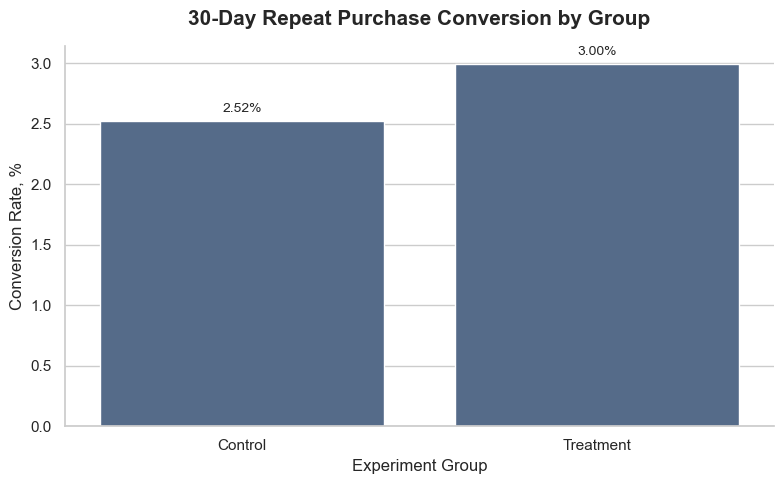

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    data=conversion_summary,
    x="group",
    y="conversion_rate_percent",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "30-Day Repeat Purchase Conversion by Group",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Experiment Group")
ax.set_ylabel("Conversion Rate, %")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=4,
        fontsize=10,
    )

sns.despine()
plt.tight_layout()
plt.show()

### Primary Metric Findings

The treatment group achieved a 30-day repeat purchase conversion rate of approximately **3.00%**, compared with **2.52%** in the control group.

This corresponds to an observed absolute uplift of approximately **0.48 percentage points** and a relative uplift of about **19%**.

The observed result is close to the simulated target effect: an increase from 2.5% to 3.0%. However, the visual difference alone is not sufficient to conclude that the feature is effective. The next step is to test statistical significance and calculate a confidence interval for the uplift.

### Two-Proportion Z-Test

In [21]:
control_row = conversion_summary.loc[
    conversion_summary["group"] == "Control"].iloc[0]

treatment_row = conversion_summary.loc[
    conversion_summary["group"] == "Treatment"].iloc[0]

conversion_counts = np.array(
    [
        treatment_row["conversions_count"],
        control_row["conversions_count"],
    ]
)

group_sizes = np.array(
    [
        treatment_row["customers_count"],
        control_row["customers_count"],
    ]
)

In [22]:
z_statistic, z_p_value = proportions_ztest(
    count=conversion_counts,
    nobs=group_sizes,
    alternative="two-sided",
)

z_statistic, z_p_value

(np.float64(2.634105134721151), np.float64(0.008435936222713873))

### Confidence Interval for the Absolute Uplift

In [23]:
confidence_interval = confint_proportions_2indep(
    count1=int(
        treatment_row["conversions_count"]
    ),
    nobs1=int(
        treatment_row["customers_count"]
    ),
    count2=int(
        control_row["conversions_count"]
    ),
    nobs2=int(
        control_row["customers_count"]
    ),
    method="wald",
    compare="diff",
    alpha=0.05,
)

confidence_interval

(np.float64(0.0012067780421072573), np.float64(0.008220992111243181))

In [24]:
primary_metric_test_summary = pd.DataFrame(
    {
        "metric": [
            "Control conversion",
            "Treatment conversion",
            "Absolute uplift",
            "Relative uplift",
            "Z-statistic",
            "P-value",
            "CI lower bound",
            "CI upper bound",
        ],
        "value": [
            control_conversion,
            treatment_conversion_observed,
            absolute_uplift,
            relative_uplift,
            z_statistic,
            z_p_value,
            confidence_interval[0],
            confidence_interval[1],
        ],
    }
)

primary_metric_test_summary

,metric,value
0,Control conversion,0.0252
1,Treatment conversion,0.0300
2,Absolute uplift,0.0047
3,Relative uplift,0.1868
4,Z-statistic,2.6341
5,P-value,0.0084
6,CI lower bound,0.0012
7,CI upper bound,0.0082


### Primary Metric Test Conclusion

The treatment group achieved a higher 30-day repeat purchase conversion rate than the control group.

The observed conversion increased from **2.52%** in the control group to **3.00%** in the treatment group. This corresponds to an absolute uplift of approximately **0.47 percentage points** and a relative uplift of about **18.7%**.

The two-proportion z-test produced a p-value of **0.0084**, which is below the significance level of \(0.05\). Therefore, the null hypothesis is rejected.

The 95% confidence interval for the absolute uplift ranges from approximately **0.12 to 0.82 percentage points**. Since the entire interval is above zero, the treatment effect is statistically significant.

The observed uplift is also close to the predefined minimum detectable effect of 0.5 percentage points. Therefore, the result is both statistically significant and close to the target level of practical importance.

## 6. Confidence Interval and Effect Size

### Effect Size: Cohen's h

In [25]:
observed_effect_size = proportion_effectsize(
    treatment_conversion_observed,
    control_conversion,
)

observed_effect_size

np.float64(0.028801421685669404)

In [26]:
effect_summary = pd.DataFrame(
    {
        "metric": [
            "Absolute uplift",
            "Relative uplift",
            "Cohen's h",
            "CI lower bound",
            "CI upper bound",
        ],
        "value": [
            absolute_uplift,
            relative_uplift,
            observed_effect_size,
            confidence_interval[0],
            confidence_interval[1],
        ],
    }
)

effect_summary

,metric,value
0,Absolute uplift,0.0047
1,Relative uplift,0.1868
2,Cohen's h,0.0288
3,CI lower bound,0.0012
4,CI upper bound,0.0082


### Effect Size Interpretation

Cohen's \(h\) is approximately **0.029**, which indicates a negligible standardized effect according to conventional thresholds.

This does not contradict the statistically significant result. The baseline conversion rate is very low, so even an absolute increase of less than one percentage point can correspond to a meaningful relative uplift.

In this experiment, the treatment increased conversion by approximately **18.7% relative to the control group**, while the confidence interval remained entirely above zero. Therefore, the effect is small in standardized statistical terms but can still be relevant from a business perspective.

## 7. Guardrail Metrics

### Selected Guardrail Metrics

The primary metric measures whether the recommendation block increases 30-day repeat purchase conversion. However, a positive effect on conversion should not come at the expense of order quality or customer value.

Two guardrail metrics are selected:

1. **Repeat order cancellation rate**

   This metric checks whether the treatment encourages additional purchases that customers later cancel. An increase in cancellation rate may indicate lower-quality or less relevant conversions.

2. **Average repeat order value**

   This metric checks whether the treatment increases repeat purchases only by shifting customers toward lower-value orders. A substantial decrease in average repeat order value could reduce the business value of the observed conversion uplift.

The treatment will be considered safe only if these metrics do not show a meaningful deterioration compared with the control group.

### Guardrail Metric Limitations

The guardrail metrics are simulated for this case study. In a real experiment, they should be defined before the test starts, together with acceptable deterioration thresholds and decision rules.

### Simulating Guardrail Metrics

In [27]:
control_data["canceled_repeat_order"] = np.where(
    control_data["repeat_purchase_30d"] == 1,
    rng.binomial(
        n=1,
        p=0.060,
        size=control_size,
    ),
    np.nan,
)

treatment_data["canceled_repeat_order"] = np.where(
    treatment_data["repeat_purchase_30d"] == 1,
    rng.binomial(
        n=1,
        p=0.062,
        size=treatment_size,
    ),
    np.nan,
)

In [28]:
control_data["repeat_order_value"] = np.where(
    control_data["repeat_purchase_30d"] == 1,
    rng.gamma(
        shape=2.5,
        scale=60,
        size=control_size,
    ),
    np.nan,
)

treatment_data["repeat_order_value"] = np.where(
    treatment_data["repeat_purchase_30d"] == 1,
    rng.gamma(
        shape=2.5,
        scale=59,
        size=treatment_size,
    ),
    np.nan,
)

In [29]:
experiment_data = pd.concat(
    [
        control_data,
        treatment_data,
    ],
    ignore_index=True,
)

### Guardrail Metric Summary

In [30]:
guardrail_summary = (
    experiment_data
    .groupby("group")
    .agg(
        converted_customers=(
            "repeat_purchase_30d",
            "sum",
        ),
        cancellation_rate=(
            "canceled_repeat_order",
            "mean",
        ),
        average_repeat_order_value=(
            "repeat_order_value",
            "mean",
        ),
        median_repeat_order_value=(
            "repeat_order_value",
            "median",
        ),
    )
    .reset_index()
)

guardrail_summary

,group,converted_customers,cancellation_rate,average_repeat_order_value,median_repeat_order_value
0,Control,423,0.0662,148.6290,126.8764
1,Treatment,502,0.0637,153.1463,129.3935


### Guardrail Metric Findings

The treatment group does not show an obvious deterioration in either guardrail metric.

The repeat order cancellation rate is slightly lower in the treatment group: approximately **6.37%** compared with **6.62%** in the control group.

The average repeat order value is also slightly higher in the treatment group: approximately **153.15** compared with **148.63** in the control group. The median follows the same pattern.

Descriptively, the treatment appears safe. However, these differences may be caused by random variation, especially because guardrail metrics are calculated only among customers who made a repeat purchase. Statistical tests are therefore required before making a final decision.

### Cancellation Rate Test

In [31]:
control_converted = control_data.loc[
    control_data["repeat_purchase_30d"] == 1
].copy()

treatment_converted = treatment_data.loc[
    treatment_data["repeat_purchase_30d"] == 1
].copy()

In [32]:
cancellation_counts = np.array(
    [
        treatment_converted[
            "canceled_repeat_order"
        ].sum(),
        control_converted[
            "canceled_repeat_order"
        ].sum(),
    ]
)

converted_group_sizes = np.array(
    [
        len(treatment_converted),
        len(control_converted),
    ]
)

In [33]:
cancellation_z_statistic, cancellation_p_value = (
    proportions_ztest(
        count=cancellation_counts,
        nobs=converted_group_sizes,
        alternative="two-sided",
    )
)

cancellation_z_statistic, cancellation_p_value

(np.float64(-0.15064977550025957), np.float64(0.8802519942684705))

### Cancellation Rate Confidence Interval

In [34]:
cancellation_confidence_interval = (
    confint_proportions_2indep(
        count1=int(cancellation_counts[0]),
        nobs1=int(converted_group_sizes[0]),
        count2=int(cancellation_counts[1]),
        nobs2=int(converted_group_sizes[1]),
        method="wald",
        compare="diff",
        alpha=0.05,
    )
)

cancellation_confidence_interval

(np.float64(-0.034355688587102855), np.float64(0.029458021571948344))

### Repeat Order Value Test

In [35]:
control_repeat_order_values = (
    control_converted["repeat_order_value"]
    .dropna()
)

treatment_repeat_order_values = (
    treatment_converted["repeat_order_value"]
    .dropna()
)

### Welch T-Test

In [36]:
order_value_welch_result = stats.ttest_ind(
    treatment_repeat_order_values,
    control_repeat_order_values,
    equal_var=False,
    alternative="two-sided",
)

order_value_welch_statistic = (
    order_value_welch_result.statistic
)

order_value_welch_p_value = (
    order_value_welch_result.pvalue
)

order_value_welch_statistic, order_value_welch_p_value

(np.float64(0.6998240001902514), np.float64(0.48421504290349393))

### Mann–Whitney U Test

In [37]:
order_value_mann_whitney_result = (
    stats.mannwhitneyu(
        treatment_repeat_order_values,
        control_repeat_order_values,
        alternative="two-sided",
    )
)

order_value_mann_whitney_statistic = (
    order_value_mann_whitney_result.statistic
)

order_value_mann_whitney_p_value = (
    order_value_mann_whitney_result.pvalue
)

(
    order_value_mann_whitney_statistic,
    order_value_mann_whitney_p_value,
)

(np.float64(106831.0), np.float64(0.870969427174402))

### Guardrail Test Summary

In [38]:
guardrail_test_summary = pd.DataFrame(
    {
        "metric": [
            "Cancellation rate difference",
            "Cancellation z-test p-value",
            "Cancellation CI lower bound",
            "Cancellation CI upper bound",
            "Repeat order value difference",
            "Welch p-value",
            "Mann–Whitney p-value",
        ],
        "value": [
            treatment_converted[
                "canceled_repeat_order"
            ].mean()
            - control_converted[
                "canceled_repeat_order"
            ].mean(),
            cancellation_p_value,
            cancellation_confidence_interval[0],
            cancellation_confidence_interval[1],
            treatment_repeat_order_values.mean()
            - control_repeat_order_values.mean(),
            order_value_welch_p_value,
            order_value_mann_whitney_p_value,
        ],
    }
)

guardrail_test_summary

,metric,value
0,Cancellation rate difference,-0.0024
1,Cancellation z-test p-value,0.8803
2,Cancellation CI lower bound,-0.0344
3,Cancellation CI upper bound,0.0295
4,Repeat order value difference,4.5173
5,Welch p-value,0.4842
6,Mann–Whitney p-value,0.8710


### Guardrail Test Conclusion

Neither guardrail metric shows a statistically significant difference between the control and treatment groups.

The treatment cancellation rate is approximately **0.24 percentage points lower** than the control rate. However, the p-value is **0.8803**, and the 95% confidence interval ranges from approximately **−3.44 to +2.95 percentage points**. Since the interval includes zero, the observed difference may be caused by random variation.

The average repeat order value is approximately **4.52 units higher** in the treatment group. However, both the Welch t-test and the Mann–Whitney U test produce large p-values, **0.4842** and **0.8710**, respectively. Therefore, there is no evidence that the treatment changes repeat order value.

The available results do not indicate deterioration in either guardrail metric. However, the guardrail analysis is based only on customers who made a repeat purchase, resulting in much smaller sample sizes than the primary metric analysis. Consequently, the confidence intervals are relatively wide, and the experiment cannot rule out all potentially meaningful changes in cancellation rate.

Overall, the treatment appears safe based on the observed data, but a larger sample or predefined non-inferiority thresholds would be needed for a stronger safety conclusion.

## 8. Sensitivity and Power Analysis

### Simulation-Based Power Analysis

The original sample size was calculated to provide 80% power for detecting a relative conversion uplift of 20%.

To validate this assumption and evaluate sensitivity to other effect sizes, repeated experiments are simulated for several possible treatment conversion rates.

For each effect size, statistical power is estimated as the share of simulated experiments in which the two-proportion z-test rejects the null hypothesis at the 0.05 significance level.

In [39]:
relative_uplifts = np.array(
    [
        0.00,
        0.05,
        0.10,
        0.15,
        0.20,
        0.25,
        0.30,
    ]
)

simulations_count = 1000

In [40]:
power_results = []

for relative_uplift_value in relative_uplifts:
    simulated_treatment_conversion = (
        baseline_conversion
        * (1 + relative_uplift_value)
    )

    significant_results = 0

    for _ in range(simulations_count):
        control_conversions = rng.binomial(
            n=sample_size_per_group,
            p=baseline_conversion,
        )

        treatment_conversions = rng.binomial(
            n=sample_size_per_group,
            p=simulated_treatment_conversion,
        )

        _, simulated_p_value = proportions_ztest(
            count=np.array(
                [
                    treatment_conversions,
                    control_conversions,
                ]
            ),
            nobs=np.array(
                [
                    sample_size_per_group,
                    sample_size_per_group,
                ]
            ),
            alternative="two-sided",
        )

        if simulated_p_value < significance_level:
            significant_results += 1

    estimated_power = (
        significant_results
        / simulations_count
    )

    power_results.append(
        {
            "relative_uplift_percent": (
                relative_uplift_value * 100
            ),
            "treatment_conversion_percent": (
                simulated_treatment_conversion * 100
            ),
            "estimated_power": estimated_power,
        }
    )

power_curve = pd.DataFrame(power_results)

power_curve

,relative_uplift_percent,treatment_conversion_percent,estimated_power
0,0.0000,2.5000,0.0480
1,5.0000,2.6250,0.1140
2,10.0000,2.7500,0.2920
3,15.0000,2.8750,0.5460
4,20.0000,3.0000,0.7820
5,25.0000,3.1250,0.9260
6,30.0000,3.2500,0.9840


In [41]:
power_curve["estimated_power_percent"] = (
    power_curve["estimated_power"] * 100
)

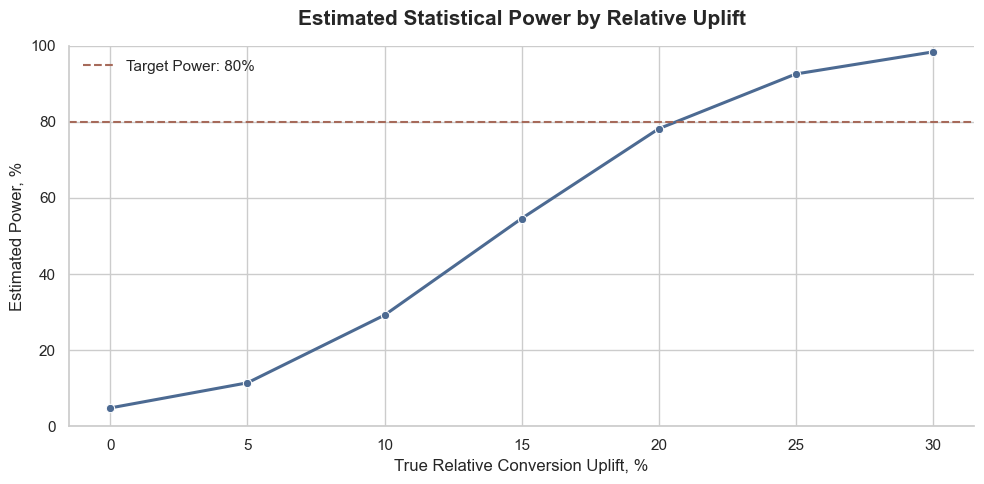

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=power_curve,
    x="relative_uplift_percent",
    y="estimated_power_percent",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.axhline(
    y=80,
    linestyle="--",
    linewidth=1.5,
    color="#A66A5A",
    label="Target Power: 80%",
)

ax.set_title(
    "Estimated Statistical Power by Relative Uplift",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("True Relative Conversion Uplift, %")
ax.set_ylabel("Estimated Power, %")
ax.set_ylim(0, 100)

ax.legend(
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

### Power Analysis Findings

The estimated statistical power increases substantially as the true treatment effect becomes larger.

When there is no real effect, the test produces a statistically significant result in approximately 5% of simulations, which is consistent with the selected significance level of 0.05.

For a 10% relative uplift, the experiment detects the effect in only about 30% of simulations. At a 15% uplift, estimated power increases to approximately 55%, but still remains below the target level.

For the planned 20% relative uplift, estimated power is close to 80%, confirming that the calculated sample size is appropriate for detecting the predefined minimum detectable effect.

Larger effects of 25–30% are detected in more than 90% of simulated experiments.

Therefore, the experiment is sufficiently powered for the target effect of 20%, but it is unlikely to reliably detect smaller improvements.

## 9. Experiment Decision

### Decision Criteria

The treatment can be recommended for rollout if all of the following conditions are satisfied:

1. The primary metric shows a statistically significant improvement at the \(0.05\) significance level.
2. The confidence interval for the absolute uplift is entirely above zero.
3. The observed uplift is large enough to be practically meaningful.
4. No statistically significant deterioration is detected in the guardrail metrics.
5. No sample ratio mismatch is detected.

In [43]:
experiment_decision_summary = pd.DataFrame(
    {
        "criterion": [
            "No sample ratio mismatch",
            "Primary metric is statistically significant",
            "Confidence interval is above zero",
            "Observed uplift is close to target MDE",
            "Cancellation rate does not deteriorate",
            "Repeat order value does not deteriorate",
        ],
        "result": [
            srm_p_value >= significance_level,
            z_p_value < significance_level,
            confidence_interval[0] > 0,
            absolute_uplift >= absolute_mde * 0.9,
            cancellation_p_value >= significance_level,
            (
                order_value_welch_p_value
                >= significance_level
                and order_value_mann_whitney_p_value
                >= significance_level
            ),
        ],
    }
)

experiment_decision_summary

,criterion,result
0,No sample ratio mismatch,True
1,Primary metric is statistically significant,True
2,Confidence interval is above zero,True
3,Observed uplift is close to target MDE,True
4,Cancellation rate does not deteriorate,True
5,Repeat order value does not deteriorate,True


In [44]:
rollout_recommended = (
    experiment_decision_summary["result"].all()
)

rollout_recommended

np.True_

In [45]:
experiment_decision_summary["status"] = np.where(
    experiment_decision_summary["result"],
    "Passed",
    "Failed",
)

experiment_decision_summary[
    [
        "criterion",
        "status",
    ]
]

,criterion,status
0,No sample ratio mismatch,Passed
1,Primary metric is statistically significant,Passed
2,Confidence interval is above zero,Passed
3,Observed uplift is close to target MDE,Passed
4,Cancellation rate does not deteriorate,Passed
5,Repeat order value does not deteriorate,Passed


### Experiment Decision

The simulated experiment meets all predefined decision criteria.

The treatment produces a statistically significant increase in 30-day repeat purchase conversion. The observed uplift is approximately 0.47 percentage points, or 18.7% relative to the control group, and the confidence interval remains entirely above zero.

No sample ratio mismatch is detected, and neither guardrail metric shows statistically significant deterioration.

Therefore, the treatment can be recommended for rollout in this simulated case study.

In a real product environment, a gradual rollout would still be preferable. The feature could first be released to a larger share of customers while monitoring cancellation rate, repeat order value, technical performance, and longer-term retention.

## 10. Key Findings

### Key Takeaways

1. The experiment was designed to evaluate whether a personalized recommendation block increases 30-day repeat purchase conversion.

2. With a baseline conversion rate of 2.5% and a relative MDE of 20%, approximately 17,000 customers were required in each experimental group to achieve 80% statistical power.

3. The simulated treatment increased conversion from approximately 2.52% to 3.00%.

4. The observed absolute uplift was approximately 0.47 percentage points, corresponding to a relative uplift of about 18.7%.

5. The primary metric result was statistically significant, with a p-value of 0.0084 and a confidence interval entirely above zero.

6. Cohen's \(h\) was small in standardized terms, but the relative uplift may still be meaningful because the baseline conversion rate is low.

7. No sample ratio mismatch was detected.

8. Neither cancellation rate nor repeat order value showed statistically significant deterioration.

9. Simulation-based power analysis confirmed that the selected sample size provides approximately 80% power for detecting the planned 20% relative uplift.

10. The treatment can therefore be recommended for rollout within the simulated experiment.

### Limitations

- The experiment data is simulated and does not represent a real Olist product experiment.
- The baseline conversion and treatment effect were selected as realistic assumptions rather than estimated from a randomized experiment.
- Guardrail metrics were analyzed only among converted customers, resulting in smaller samples and wider confidence intervals.
- No long-term effects on retention, customer lifetime value, or recommendation fatigue were evaluated.
- In a real experiment, eligibility rules, exposure logging, novelty effects, technical failures, and heterogeneous treatment effects should also be examined.

In [46]:
final_decision = pd.DataFrame(
    {
        "experiment_result": [
            (
                "Recommend rollout"
                if rollout_recommended
                else "Do not recommend rollout"
            )
        ],
        "absolute_uplift_pp": [
            absolute_uplift * 100
        ],
        "relative_uplift_percent": [
            relative_uplift * 100
        ],
        "primary_metric_p_value": [
            z_p_value
        ],
        "ci_lower_bound_pp": [
            confidence_interval[0] * 100
        ],
        "ci_upper_bound_pp": [
            confidence_interval[1] * 100
        ],
    }
)

final_decision

,experiment_result,absolute_uplift_pp,relative_uplift_percent,primary_metric_p_value,ci_lower_bound_pp,ci_upper_bound_pp
0,Recommend rollout,0.4714,18.6761,0.0084,0.1207,0.8221
